In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [7]:
features= ['pclass','fare','sex','embarked','age']
target = ['survived']

In [10]:
## Missing Data
from sklearn.impute import SimpleImputer

median_impute = SimpleImputer(strategy="median")
freq_impute = SimpleImputer(strategy="most_frequent")

df[['age']] = median_impute.fit_transform(df[['age']])
df[['embarked']] = freq_impute.fit_transform(df[['embarked']])

In [11]:
df.isna().sum()

survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
## Encoding
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['sex'] = label.fit_transform(df['sex'])
df['embarked'] = label.fit_transform(df['embarked'])

In [13]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [16]:
X = df[features]
y =df[target]

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
## Decision Tree - no pruning
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

tree= DecisionTreeClassifier()
tree.fit(X_train,y_train)

tree_pred = tree.predict(X_test)
print("Accuracy Score: ", accuracy_score(y_test,tree_pred))

Accuracy Score:  0.7597765363128491


### Drawing the Tree

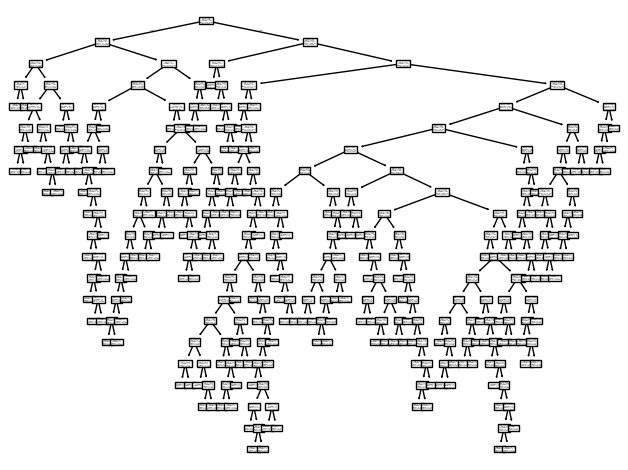

In [21]:
from sklearn.tree import plot_tree

plt.Figure(figsize=(28,10))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["Died","Survived"]
)
plt.tight_layout()
plt.show()

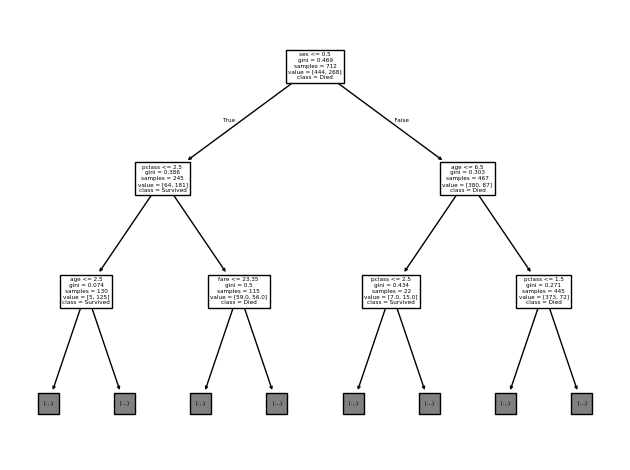

In [24]:
plt.Figure(figsize=(28,10))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    max_depth=2
)
plt.tight_layout()
plt.show()

### Pre Pruning Implementation

In [26]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
max_depths = [2,3,4,5,6,7,8,9,10]

for depth in max_depths:

    tree= DecisionTreeClassifier(max_depth=depth)
    tree.fit(X_train,y_train)

    tree_pred = tree.predict(X_test)
    print(f"Accuracy Scorefor {depth} depth: ", accuracy_score(y_test,tree_pred))

Accuracy Scorefor 2 depth:  0.7653631284916201
Accuracy Scorefor 3 depth:  0.7988826815642458
Accuracy Scorefor 4 depth:  0.7988826815642458
Accuracy Scorefor 5 depth:  0.7988826815642458
Accuracy Scorefor 6 depth:  0.8044692737430168
Accuracy Scorefor 7 depth:  0.7988826815642458
Accuracy Scorefor 8 depth:  0.7988826815642458
Accuracy Scorefor 9 depth:  0.7877094972067039
Accuracy Scorefor 10 depth:  0.7932960893854749


In [30]:
min_samples_splits = [10,15,20,25,30]

for min_sample in min_samples_splits:

    tree= DecisionTreeClassifier(max_depth=6,min_samples_split=min_sample)
    tree.fit(X_train,y_train)

    tree_pred = tree.predict(X_test)
    print(f"Accuracy Scorefor {min_sample} min sample depth: ", accuracy_score(y_test,tree_pred))

Accuracy Scorefor 10 min sample depth:  0.8100558659217877
Accuracy Scorefor 15 min sample depth:  0.8044692737430168
Accuracy Scorefor 20 min sample depth:  0.8044692737430168
Accuracy Scorefor 25 min sample depth:  0.7988826815642458
Accuracy Scorefor 30 min sample depth:  0.7877094972067039


### Post Pruning Implementation

In [31]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
paths = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = paths.ccp_alphas

In [35]:
ccp_alphas

array([0.00000000e+00, 0.00000000e+00, 6.68806849e-05, 1.45921494e-04,
       1.84428555e-04, 2.00642055e-04, 2.34082397e-04, 2.34082397e-04,
       3.51123596e-04, 4.68164794e-04, 4.68164794e-04, 5.61797753e-04,
       6.24219725e-04, 6.67991230e-04, 7.02247191e-04, 7.02247191e-04,
       8.19288390e-04, 8.19288390e-04, 8.32292967e-04, 8.42696629e-04,
       8.42696629e-04, 8.42696629e-04, 8.94231048e-04, 8.99610781e-04,
       9.24769963e-04, 9.36329588e-04, 9.36329588e-04, 9.36329588e-04,
       9.88347898e-04, 1.00253471e-03, 1.05337079e-03, 1.07400895e-03,
       1.08038029e-03, 1.11865144e-03, 1.12359551e-03, 1.12359551e-03,
       1.13139825e-03, 1.17041199e-03, 1.18841832e-03, 1.22566125e-03,
       1.22893258e-03, 1.22893258e-03, 1.24361593e-03, 1.24843945e-03,
       1.27565833e-03, 1.30996111e-03, 1.33761370e-03, 1.37044603e-03,
       1.46301498e-03, 1.47927070e-03, 1.51142557e-03, 1.54072312e-03,
       1.56675436e-03, 1.60434338e-03, 1.66892062e-03, 1.76144762e-03,
      

In [36]:
# train the model fpr all alphas
tree = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train,y_train)
    tree.append((model,alpha))

In [39]:
best_acc= 0
best_alpha = 0
for  model, alpha in tree:
    curr_acc = model.score(X_test,y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [40]:
print("best_acc: ", best_acc)
print("best_alpha: ", best_alpha)

best_acc:  0.8379888268156425
best_alpha:  0.0015407231242023183


In [ ]:
best_model = DecisionTreeClassifier(ccp_alpha=best_alpha)

In [42]:
best_model.fit(X_train,y_train)
best_model.score(X_test,y_test)


0.8379888268156425

### Combination of post and pre pruning

In [48]:
combined = DecisionTreeClassifier(ccp_alpha=best_alpha,max_depth=15)
combined.fit(X_train,y_train)
combined.score(X_test,y_test)

0.8324022346368715